In [14]:
source("Main.R")
source("Utilities.R")
source("Conf.R")

In [15]:
allDrugCond=list()

##TODO: "Lexibulin" is missing due to an edge case in pdex
for(elem in c("AR-A014418", "AZD4573", "CHIR", "CHIR-98014",
              "DMSO_round2", "KYA", "LDN", "PFI1", "PP121","Lexibulin",
              "RGFP", "Romidepsin", "Stattic")){
    myCond=read.csv(paste0("./",elem,"/",elem,"_versusDMSO.csv"))
    allDrugCond <- lappend(allDrugCond, myCond)
}
allDrugCond <- data.frame(do.call(rbind,allDrugCond))


In [16]:
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
rownames(SampleSheet)=SampleSheet$SampleName

In [17]:
FCs = reshape(allDrugCond[,c("target","feature","percent_change")],
              idvar = "target", timevar="feature", direction = "wide")
FDRs = reshape(allDrugCond[,c("target","feature","fdr")],
               idvar = "target", timevar="feature",direction = "wide") 


In [18]:
rownames(FCs)=FCs$target
rownames(FDRs)=FDRs$target
FCs$target=NULL
FDRs$target=NULL


FCs[is.na(FCs)] <- 0
FCs[abs(FCs) < 0.2] <- 0
FDRs[is.na(FDRs)] <- 1  # assume NA FDRs are non-significant
FCs[FDRs >= 0.05] <- 0

FCs_binary = copy(FCs)
FCs_binary[FCs_binary>0] = 1
FCs_binary[FCs_binary<0] = -1

In [19]:
# Compute Jaccard similarity AND intersection counts between rows of a binary (0/1) matrix
jaccard_and_overlap <- function(mat_binary) {
  # mat_binary: matrix with entries 0/1 (rows = drugs, cols = genes)

  # Intersection = number of shared 1s between each pair of rows
  intersection <- tcrossprod(mat_binary)  # (n_drugs x n_drugs)

  # Row sums = number of 1s in each drug
  row_sums <- rowSums(mat_binary)

  # Union = |A| + |B| - intersection
  union <- outer(row_sums, row_sums, "+") - intersection

  # Jaccard = intersection / union
  jaccard <- intersection / union

  # Avoid NaN when union == 0 (no 1s in either drug)
  jaccard[union == 0] <- 0

  list(
    jaccard = jaccard,
    overlap = intersection  # this is the number of overlapping 1s
  )
}


compute_up_down_jaccard <- function(df) {
  # df: data frame or matrix with entries -1, 0, 1
  # rows = drugs, columns = genes

  mat <- as.matrix(df)

  # Binary matrices for up- and down-regulated genes
  up_binary   <- (mat == 1) * 1
  down_binary <- (mat == -1) * 1

  # Up-regulated: Jaccard + overlap
  up_res <- jaccard_and_overlap(up_binary)

  # Down-regulated: Jaccard + overlap
  down_res <- jaccard_and_overlap(down_binary)

  # Add names
  drugs <- rownames(mat)

  for (m in c("jaccard", "overlap")) {
    rownames(up_res[[m]])   <- drugs
    colnames(up_res[[m]])   <- drugs
    rownames(down_res[[m]]) <- drugs
    colnames(down_res[[m]]) <- drugs
  }

  list(
    jaccard_up   = up_res$jaccard,
    jaccard_down = down_res$jaccard,
    overlap_up   = up_res$overlap,   # number of overlapping up-regulated genes
    overlap_down = down_res$overlap  # number of overlapping down-regulated genes
  )
}

# ---- Example usage ----
res <- compute_up_down_jaccard(FCs_binary)
jaccard_up=res$jaccard_up
jaccard_down=res$jaccard_down
overlap_up=res$overlap_up
overlap_down=res$overlap_down


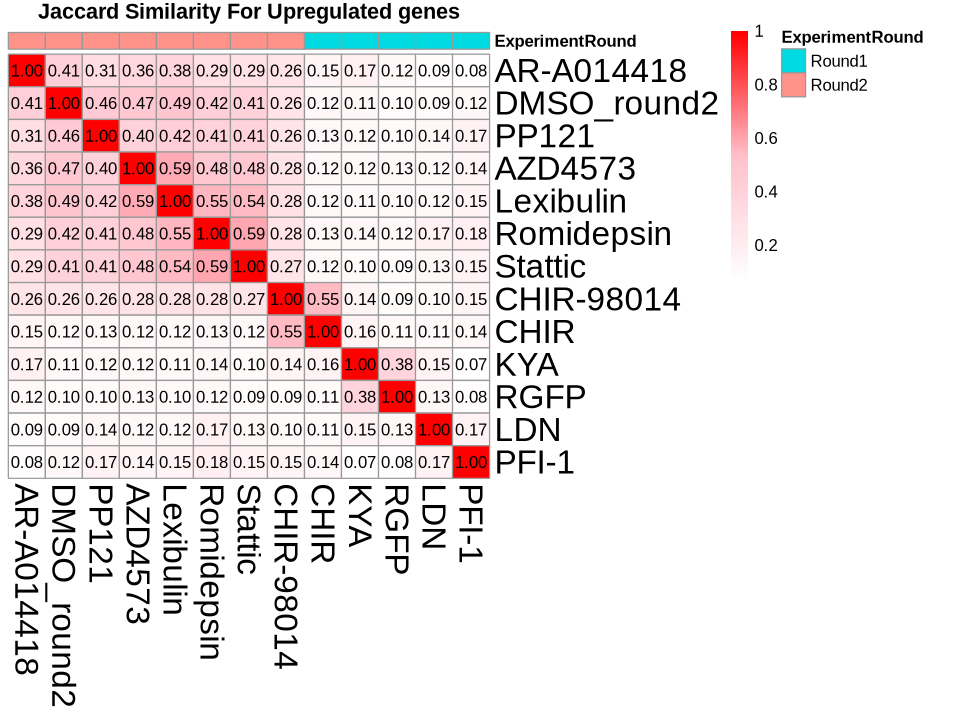

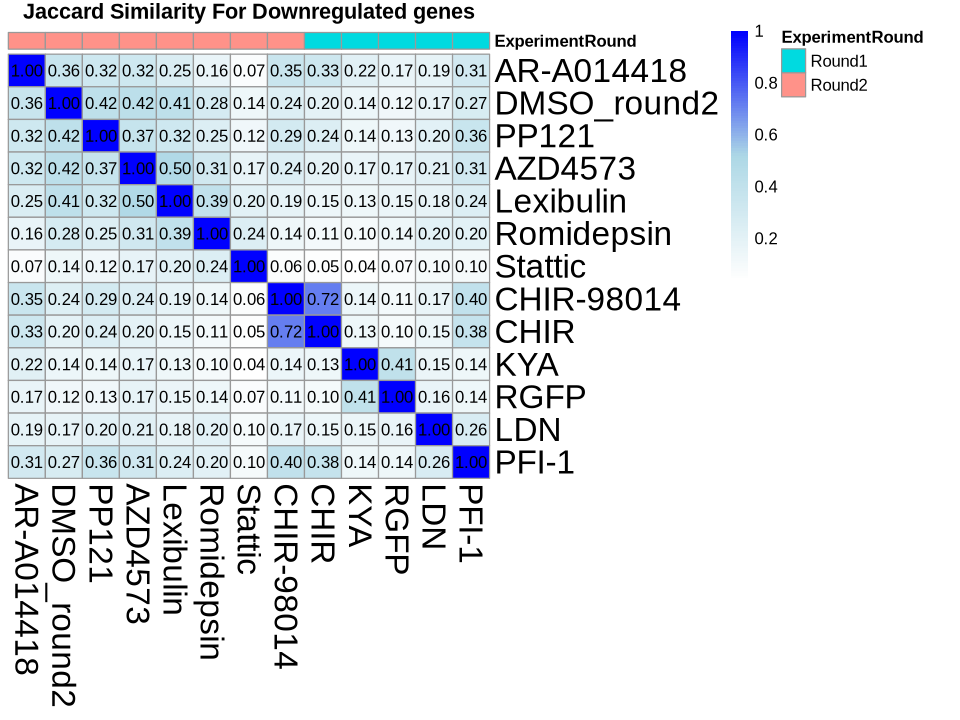

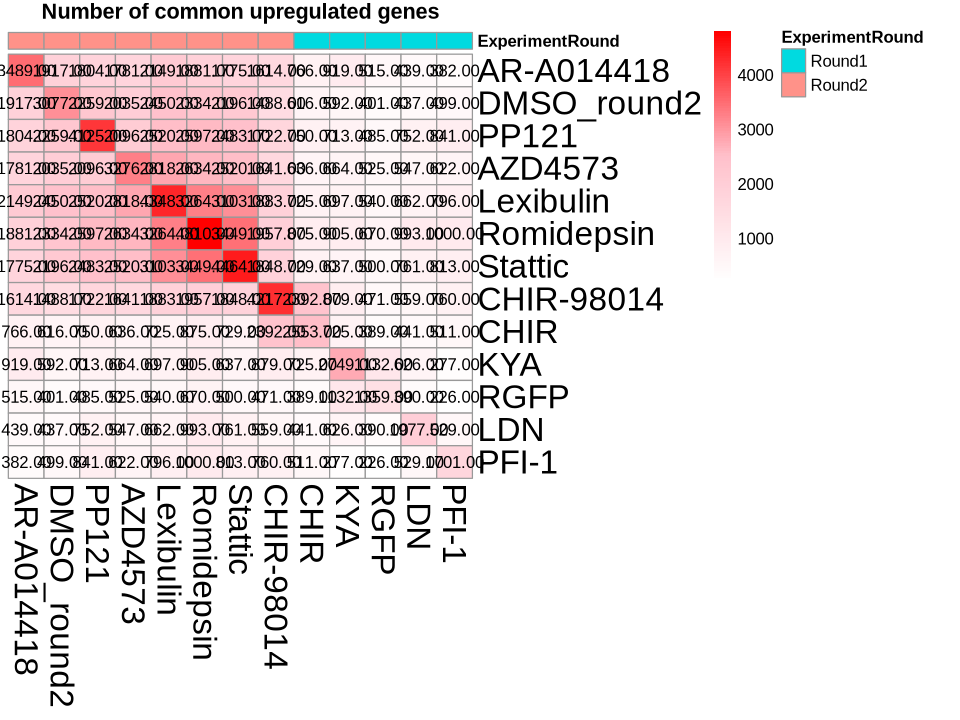

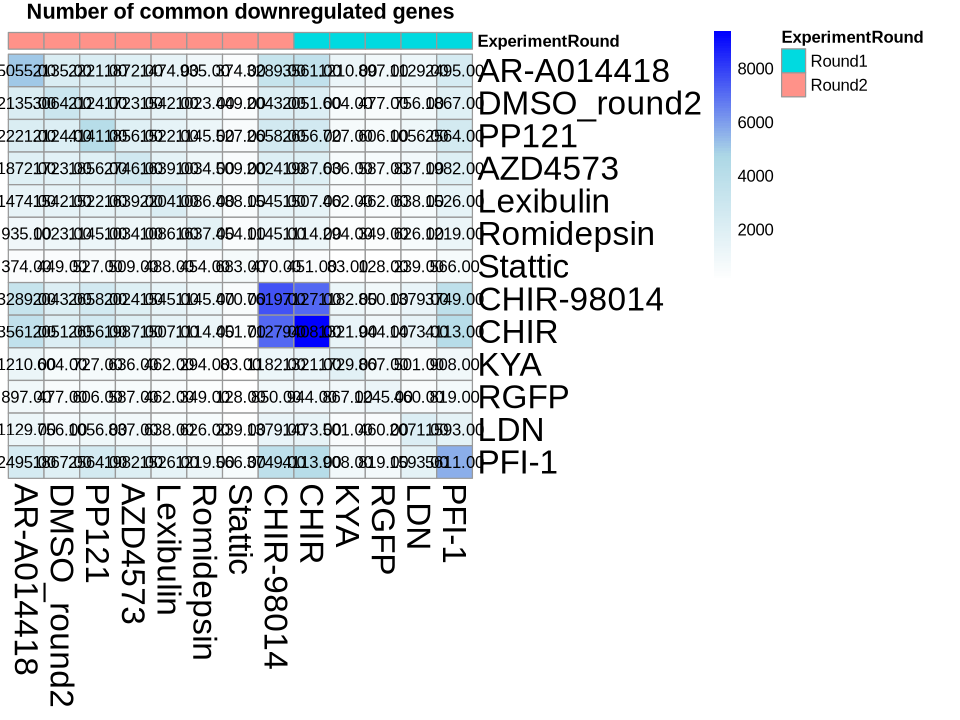

In [20]:
options(repr.plot.width = 8, repr.plot.height = 6)
drugOrder=c('AR-A014418','DMSO_round2','PP121','AZD4573','Lexibulin','Romidepsin',
            'Stattic','CHIR-98014','CHIR','KYA','RGFP','LDN','PFI-1')

plotHeatmaps <- function(inDat,drugOrder,SampleSheet,mainStr,colorCode){
    inDat=inDat[drugOrder,drugOrder]
    SampleSheet <- SampleSheet[rownames(jaccard_up),]
    annots=copy(SampleSheet)
    annots$SampleName=NULL
    
    pheatmap(
      inDat,
      display_numbers = TRUE,
      cluster_rows = FALSE,cluster_cols = FALSE,
      number_color = "black",
      fontsize_number = 10,
      fontsize_col=20,fontsize_row=20,
      annotation_col=annots,
      color = colorRampPalette(colorCode)(100),
      main = mainStr
    )

}
plotHeatmaps(res$jaccard_up,drugOrder,SampleSheet,
             mainStr="Jaccard Similarity For Upregulated genes",
             colorCode=c("white", "pink", "red"))
plotHeatmaps(res$jaccard_down,drugOrder,SampleSheet,
             mainStr="Jaccard Similarity For Downregulated genes",
            colorCode=c("white", "lightblue", "blue"))
plotHeatmaps(res$overlap_up,drugOrder,SampleSheet,
             mainStr="Number of common upregulated genes",
            colorCode=c("white", "pink", "red"))
plotHeatmaps(res$overlap_down,drugOrder,SampleSheet,
             mainStr="Number of common downregulated genes",
            colorCode=c("white", "lightblue", "blue"))

In [21]:
# Mask non-significant fold changes

#FCs[abs(FCs) < 0.1] <- 0

# Count up/down regulated genes per row
nUpRegGenes <- rowSums(FCs > 0)
nDownRegGenes <- rowSums(FCs < 0)

tmp <- data.frame("PerturbationName"= names(nUpRegGenes),
                   "N_upRegGenes"=nUpRegGenes,
                   "N_downRegGenes"=nDownRegGenes,
                   "N_totalRegGenes" = nUpRegGenes+nDownRegGenes,
                   "Condition"=elem)
tmp

,PerturbationName,N_upRegGenes,N_downRegGenes,N_totalRegGenes,Condition
,<chr>,<dbl>,<dbl>,<dbl>,<chr>
AR-A014418,AR-A014418,3489,5055,8544,Stattic
AZD4573,AZD4573,3276,2746,6022,Stattic
CHIR,CHIR,2553,9408,11961,Stattic
CHIR-98014,CHIR-98014,4217,7619,11836,Stattic
DMSO_round2,DMSO_round2,3077,3064,6141,Stattic
KYA,KYA,2749,1729,4478,Stattic
LDN,LDN,1977,2071,4048,Stattic
PFI-1,PFI-1,1701,5611,7312,Stattic
PP121,PP121,4125,4141,8266,Stattic


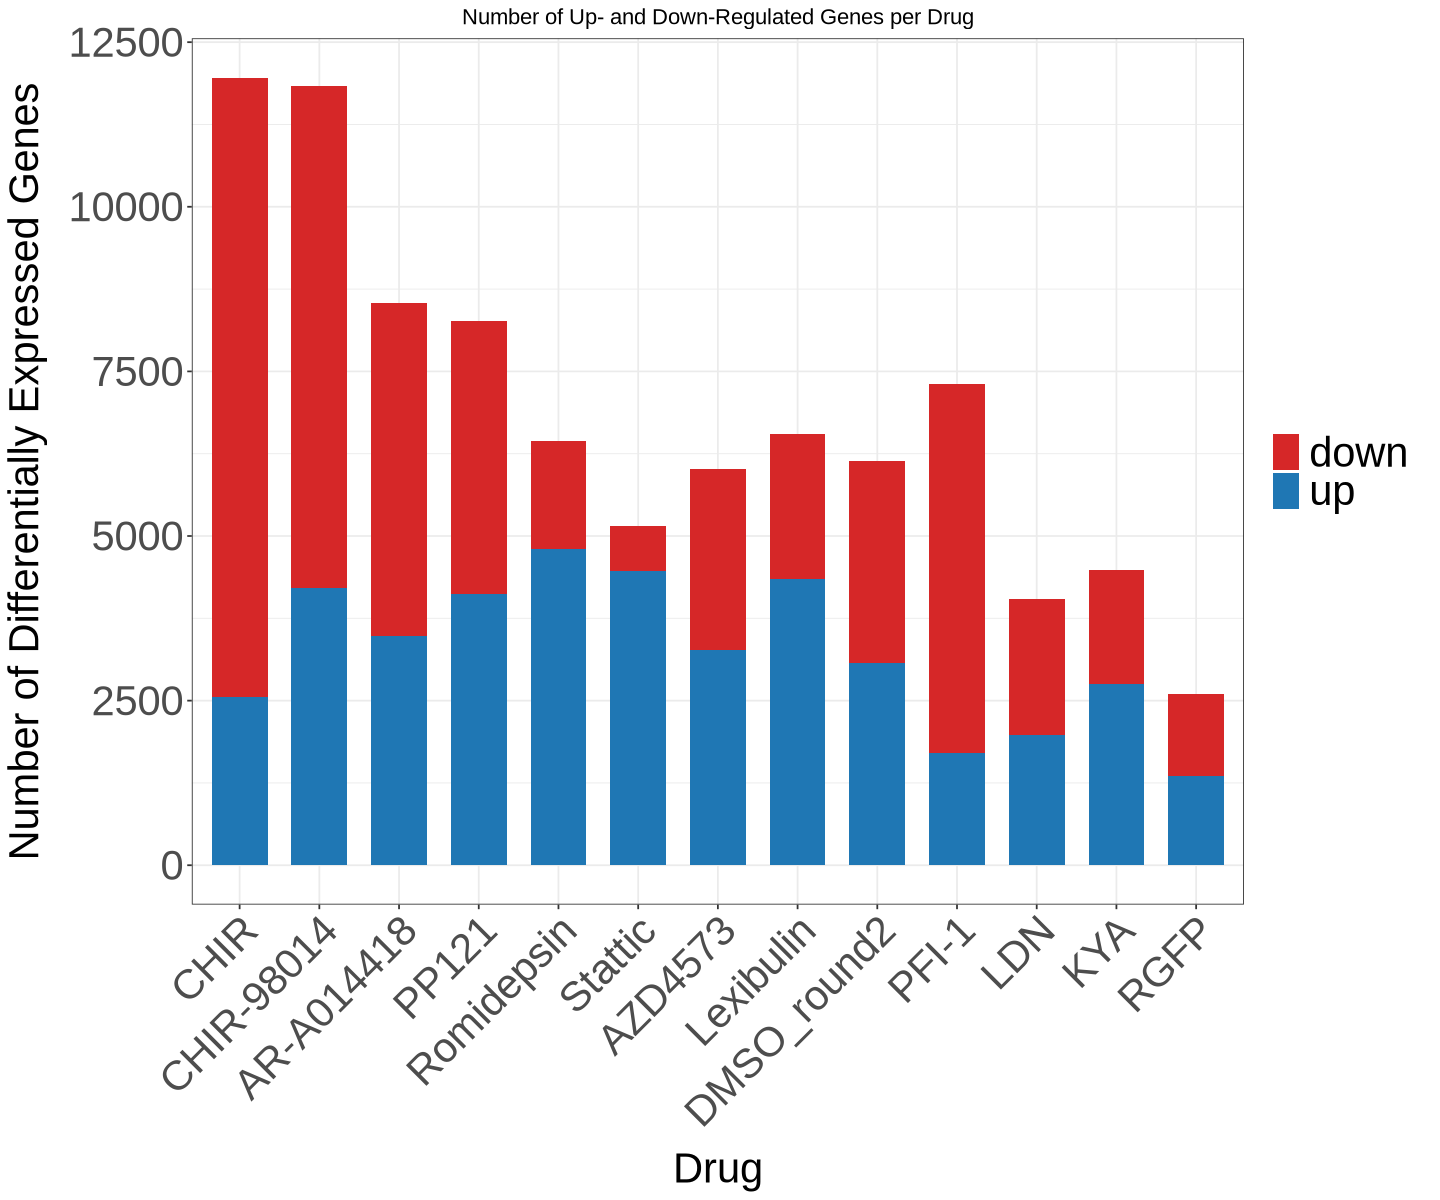

In [22]:
options(repr.plot.width = 12, repr.plot.height = 10)

library(ggplot2)
library(dplyr)
library(tidyr)

mat <- as.matrix(FCs_binary)

df_counts <- data.frame(
drug = rownames(mat),
up = rowSums(mat == 1),
down = rowSums(mat == -1)
) %>%
pivot_longer(cols = c("up", "down"),
             names_to = "direction",
             values_to = "count")

df_counts$drug = factor(df_counts$drug, levels = c("CHIR", "CHIR-98014", "AR-A014418","PP121",
                                                   "Romidepsin","Stattic","AZD4573","Lexibulin",
                                                   "DMSO_round2","PFI-1","LDN","KYA","RGFP"))

ggplot(df_counts, aes(x = drug, y = count, fill = direction)) +
geom_bar(stat = "identity", position = "STACK", width = 0.7) +
theme_bw() +
theme(
  axis.text.x = element_text(angle = 45, hjust = 1, size = 25),
  plot.title = element_text(hjust = 0.5),
  legend.title = element_blank(),
  legend.text=element_text(size=25),
  axis.title=element_text(size=25),
  axis.text=element_text(size=25)
) +
labs(
  title = "Number of Up- and Down-Regulated Genes per Drug",
  x = "Drug",
  y = "Number of Differentially Expressed Genes"
) +
scale_fill_manual(values = c("up" = "#1f77b4", "down" = "#d62728"))


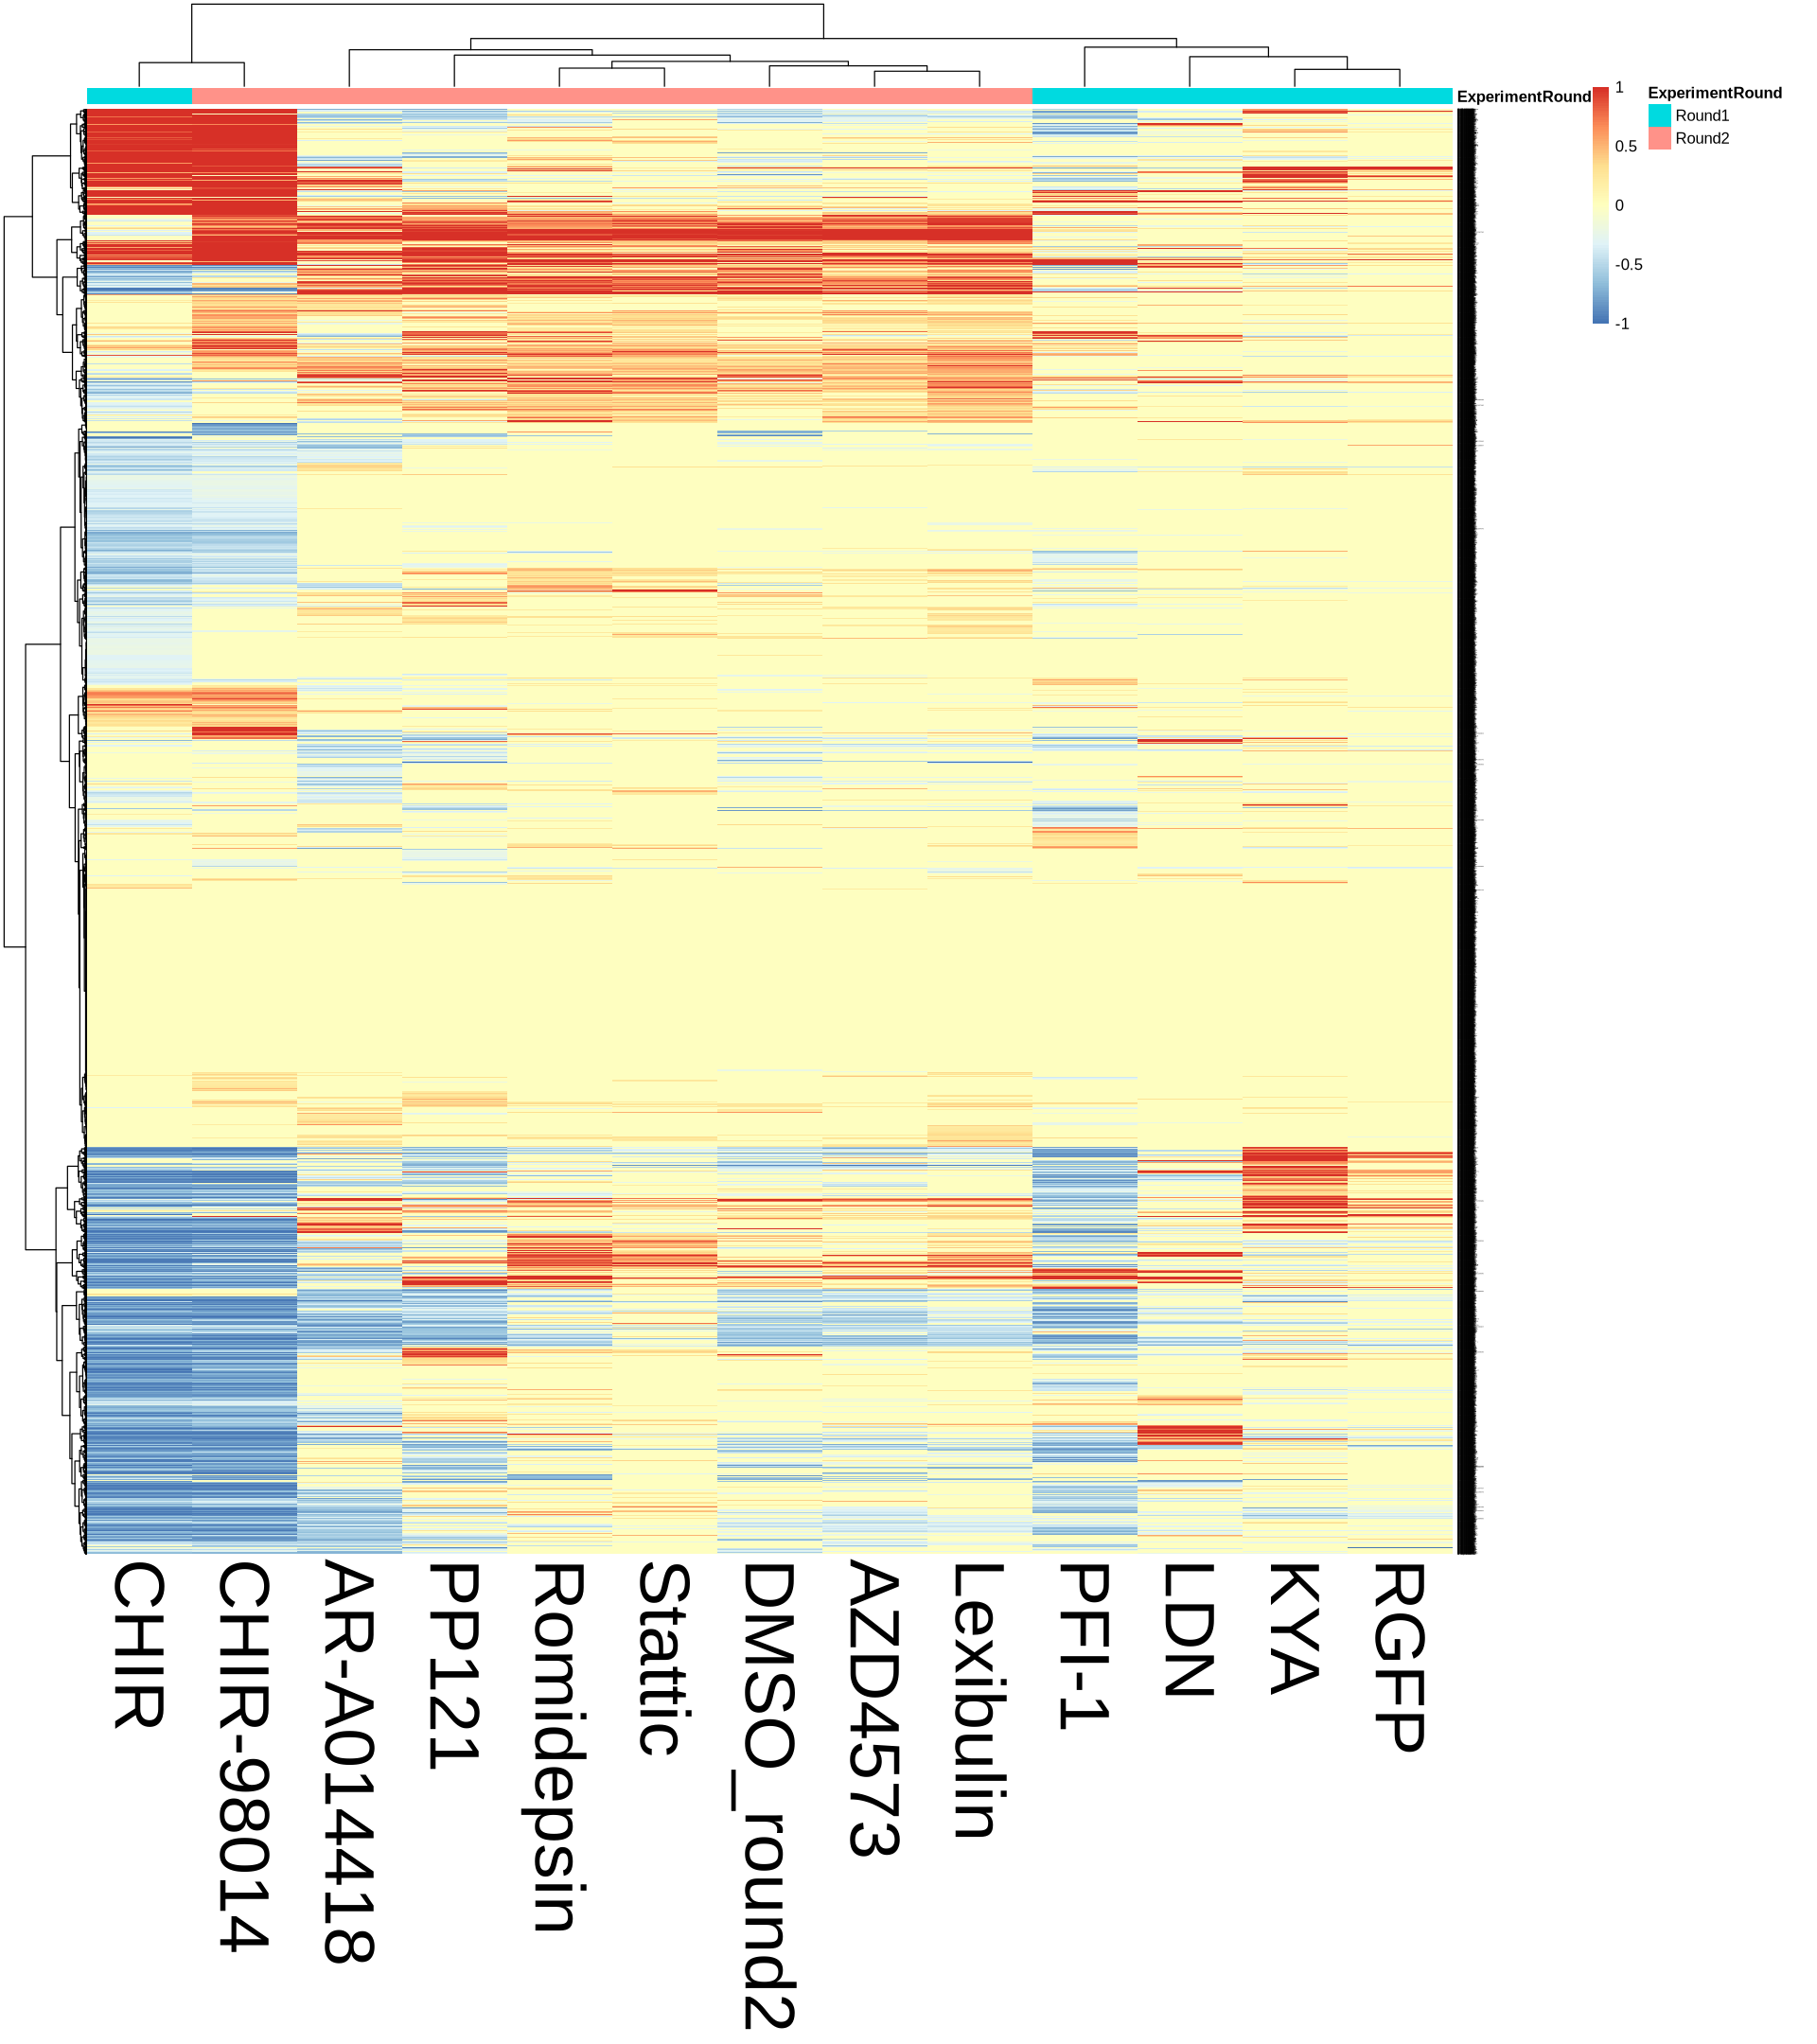

In [23]:
options(repr.plot.width = 16, repr.plot.height = 18)

FCs_copy=copy(FCs)
FCs_copy[FDRs >0.1] = 0

FCs_copy[FCs_copy>1]=1
FCs_copy[FCs_copy< -1]= -1

SampleSheet <- SampleSheet[rownames(FCs_copy),]
annots=copy(SampleSheet)
annots$SampleName=NULL


pheatmap(t(FCs_copy), na_col = "grey", 
  clustering_method = "ward.D2",
         fontsize_row=1,fontsize_col=45, annotation_col=annots)

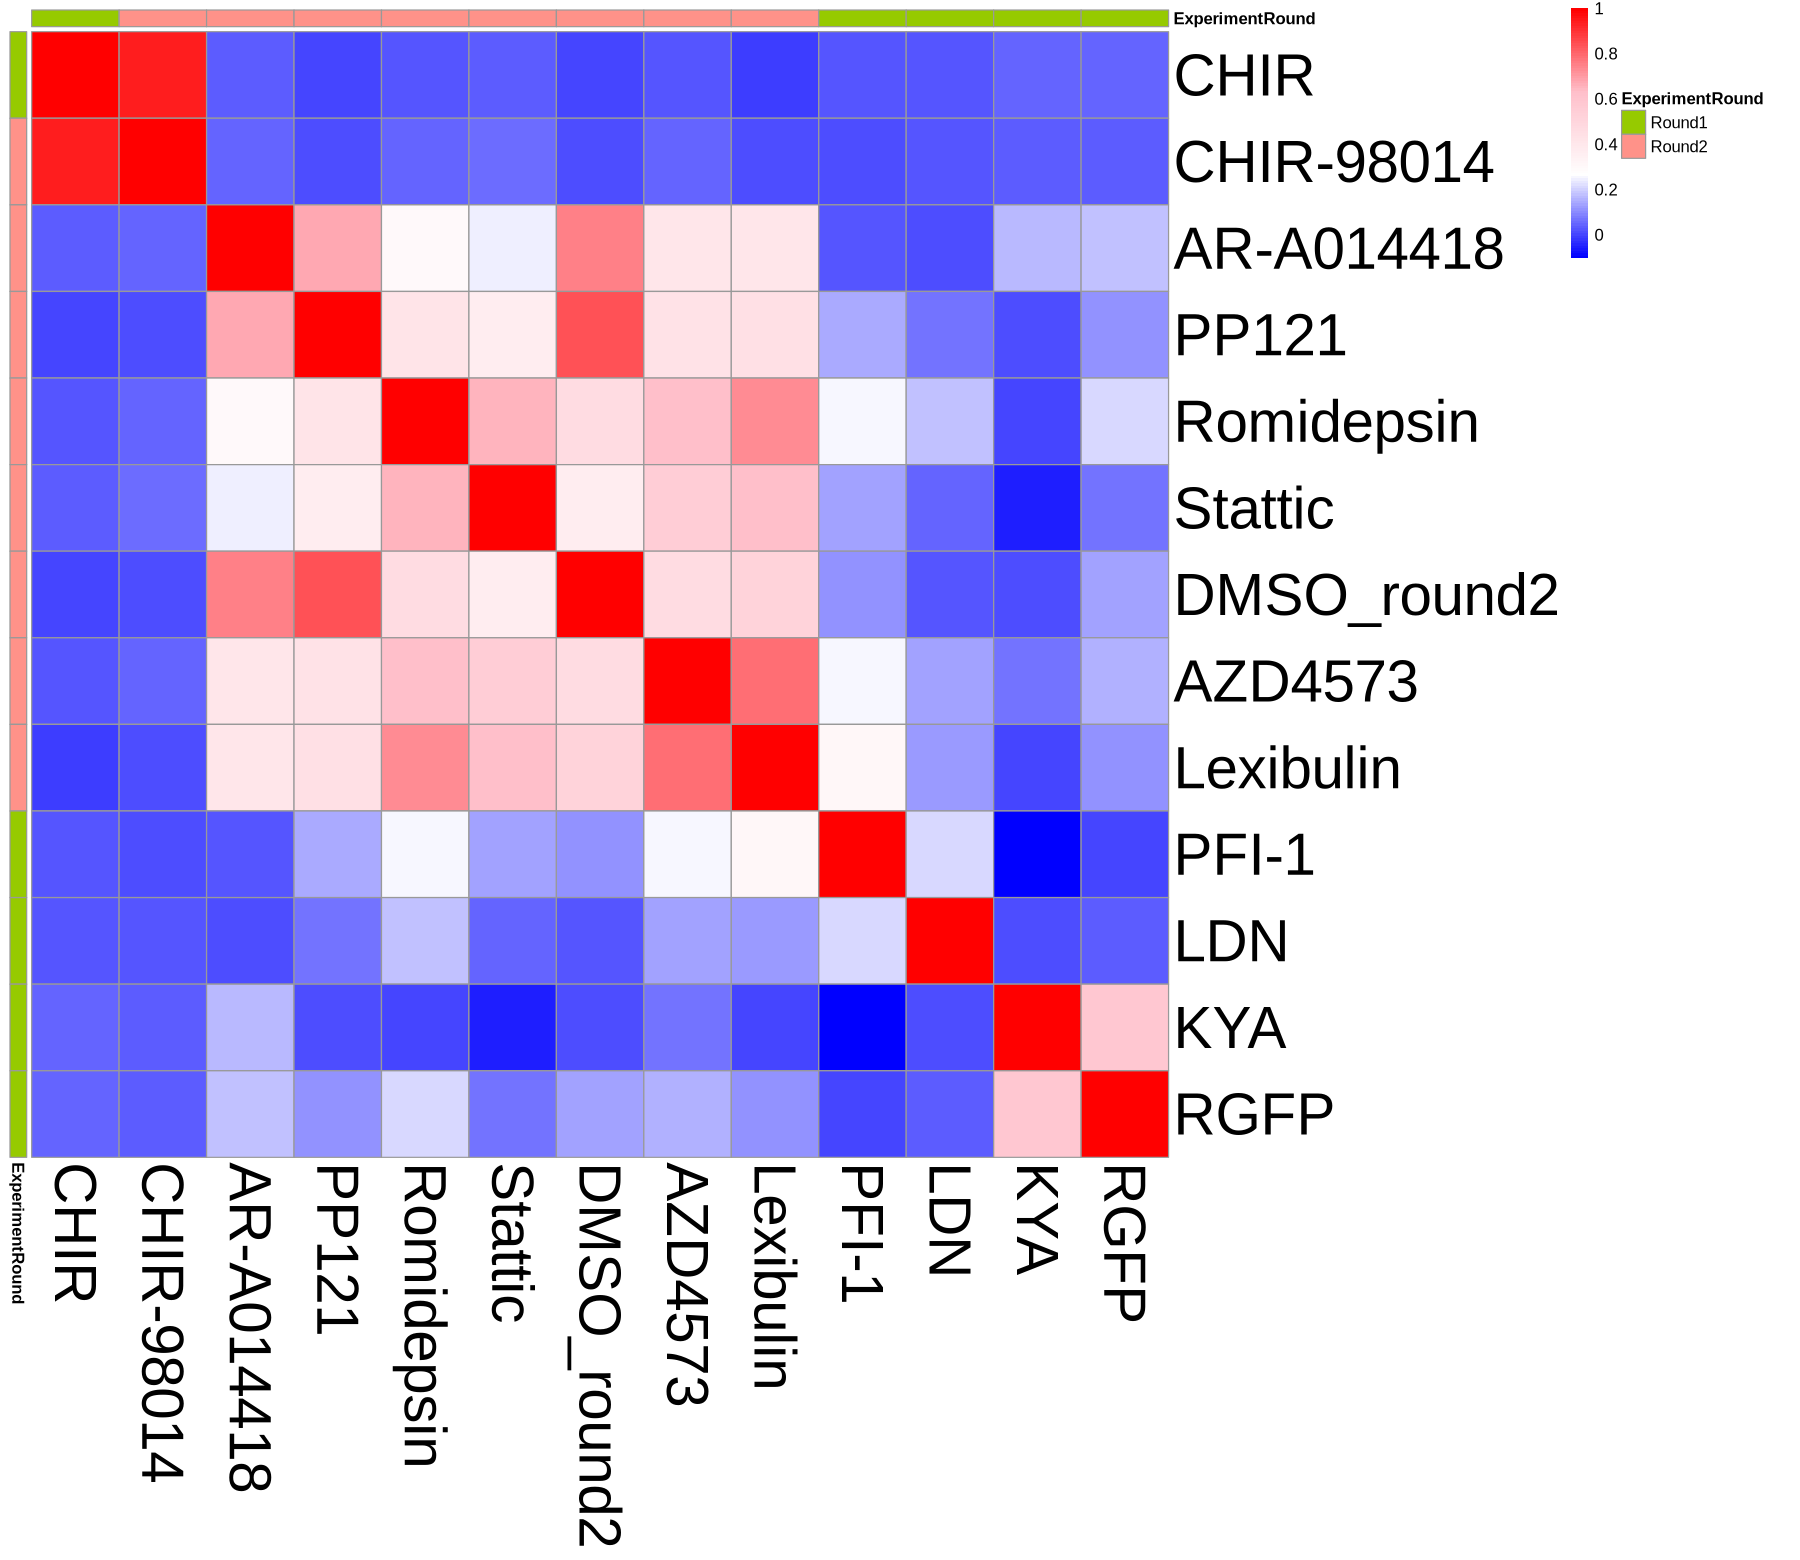

In [24]:
options(repr.plot.width = 15, repr.plot.height = 13)

FCs_copy=copy(FCs)
FCs_copy[FDRs >0.1] = 0

k=cor(t(FCs_copy), method = "pearson")
rcOrder=c("CHIR", "CHIR-98014", "AR-A014418","PP121","Romidepsin",
          "Stattic","DMSO_round2","AZD4573", "Lexibulin","PFI-1","LDN","KYA","RGFP")
k=k[rcOrder,rcOrder]

pheatmap(k, na_col = "grey", cluster_rows = FALSE,cluster_cols = FALSE,
         annotation_col=annots, annotation_row=annots,
         fontsize_row=35,fontsize_col=35, color=colorRampPalette(c("blue", "white","pink", "red"))(100))

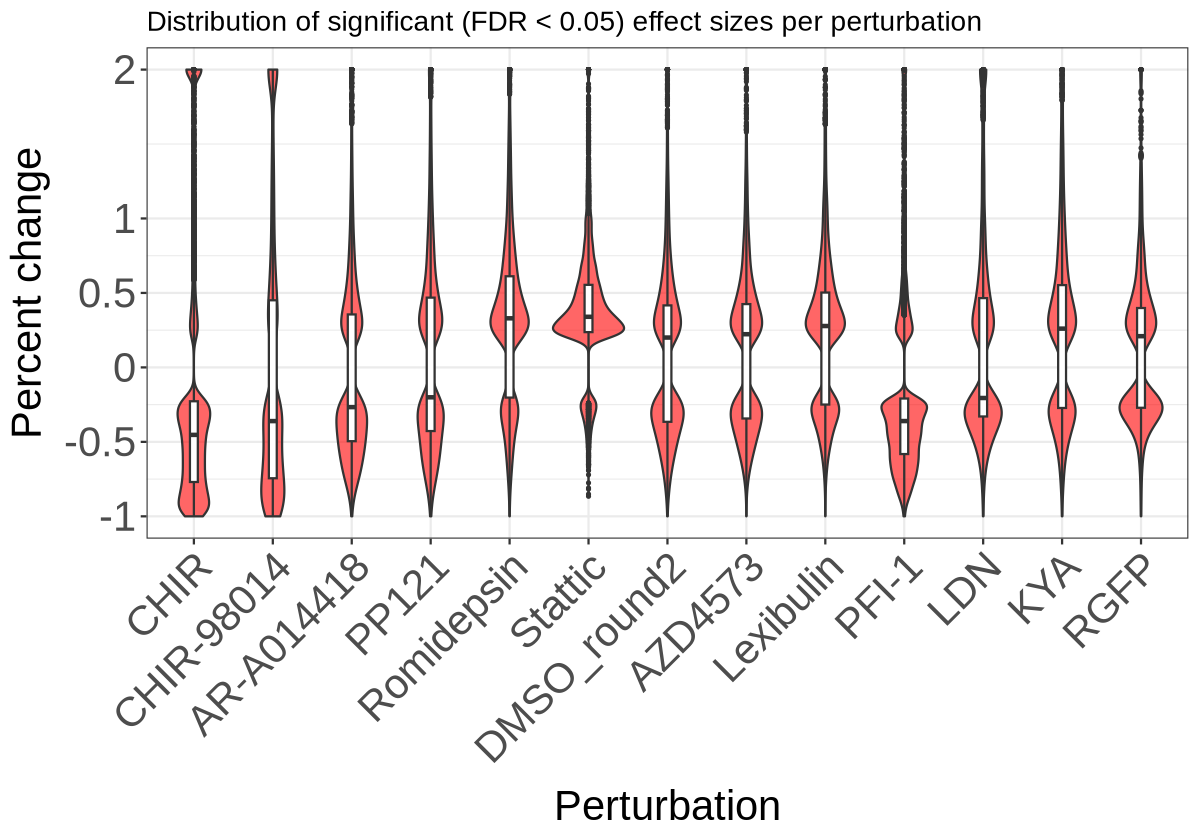

In [25]:
options(repr.plot.width = 10, repr.plot.height = 7)

library(tidyverse)

FCs_copy=copy(FCs)
FCs_copy[FCs_copy>2]=2
FCs_copy[FCs_copy< -1]= -1


# Assuming: beta_mat is a matrix with rows = perturbations, cols = genes
# Convert to long format
df_long <- as.data.frame(FCs_copy) %>%
    mutate(perturbation = rownames(FCs_copy)) %>%
    pivot_longer(
        cols = -perturbation,
        names_to = "gene",
        values_to = "beta"
    )

df_long <- df_long[df_long$beta != 0,]
df_long$perturbation<- factor(df_long$perturbation, levels=rcOrder)
# Plot
ggplot(df_long, aes(x = perturbation, y = beta)) +
    geom_violin(fill = "red", alpha = 0.6) +
    geom_boxplot(width = 0.1, outlier.size = 0.8) +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, size=25),
         axis.text.y=element_text(size=25),
         axis.title=element_text(size=25)) +
    labs(
        x = "Perturbation",
        y = "Percent change",
        title = "Distribution of significant (FDR < 0.05) effect sizes per perturbation"
    )+scale_y_continuous(
    breaks = c(-1, -0.5, 0, 0.5, 1, 2),
    labels = c("-1", "-0.5","0", "0.5","1", "2")
  )


In [27]:
drug_cosineDist = read.csv("./TextFiles/sample_distances_cosine.csv", row.names = 1)
#drug_energyDist = read.csv("./TextFiles/sample_distances_energy.csv",row.names = 1)
drug_energyDist = read.csv("./DrugEnergyDistances.csv",row.names = 1)
colnames(drug_cosineDist)=sapply(colnames(drug_cosineDist), function(x){gsub("\\.", "-", x)})
colnames(drug_energyDist)=sapply(colnames(drug_energyDist), function(x){gsub("\\.", "-", x)})

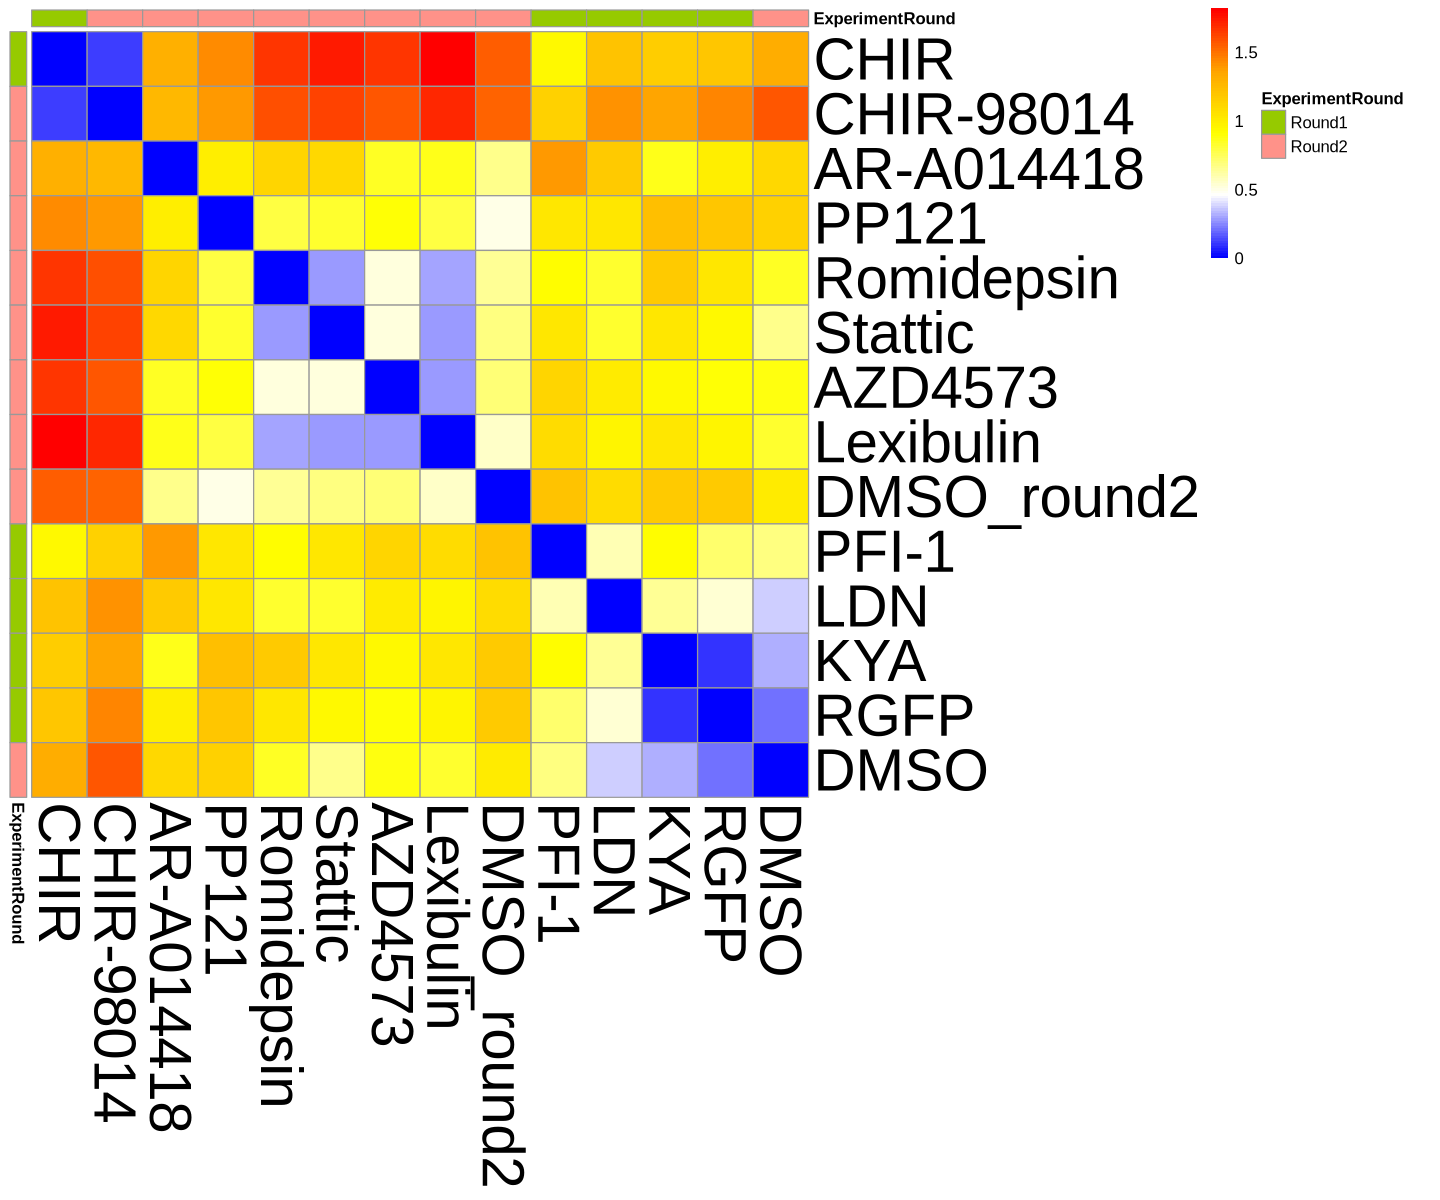

In [28]:
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[rcOrder,]
annots=copy(SampleSheet)
annots$SampleName=NULL

options(repr.plot.width = 12, repr.plot.height = 10)
rcOrder=c("CHIR", "CHIR-98014", "AR-A014418","PP121","Romidepsin",
          "Stattic","AZD4573","Lexibulin","DMSO_round2","PFI-1","LDN","KYA","RGFP","DMSO")

drug_cosineDist=drug_cosineDist[rcOrder,rcOrder]

pheatmap(drug_cosineDist, na_col = "grey", cluster_rows = FALSE,cluster_cols = FALSE, 
         fontsize_row=35,fontsize_col=35, clustering_method = "ward.D2",
         annotation_col=annots, annotation_row=annots,
         color=colorRampPalette(c("blue", "white","yellow","orange", "red"))(100))

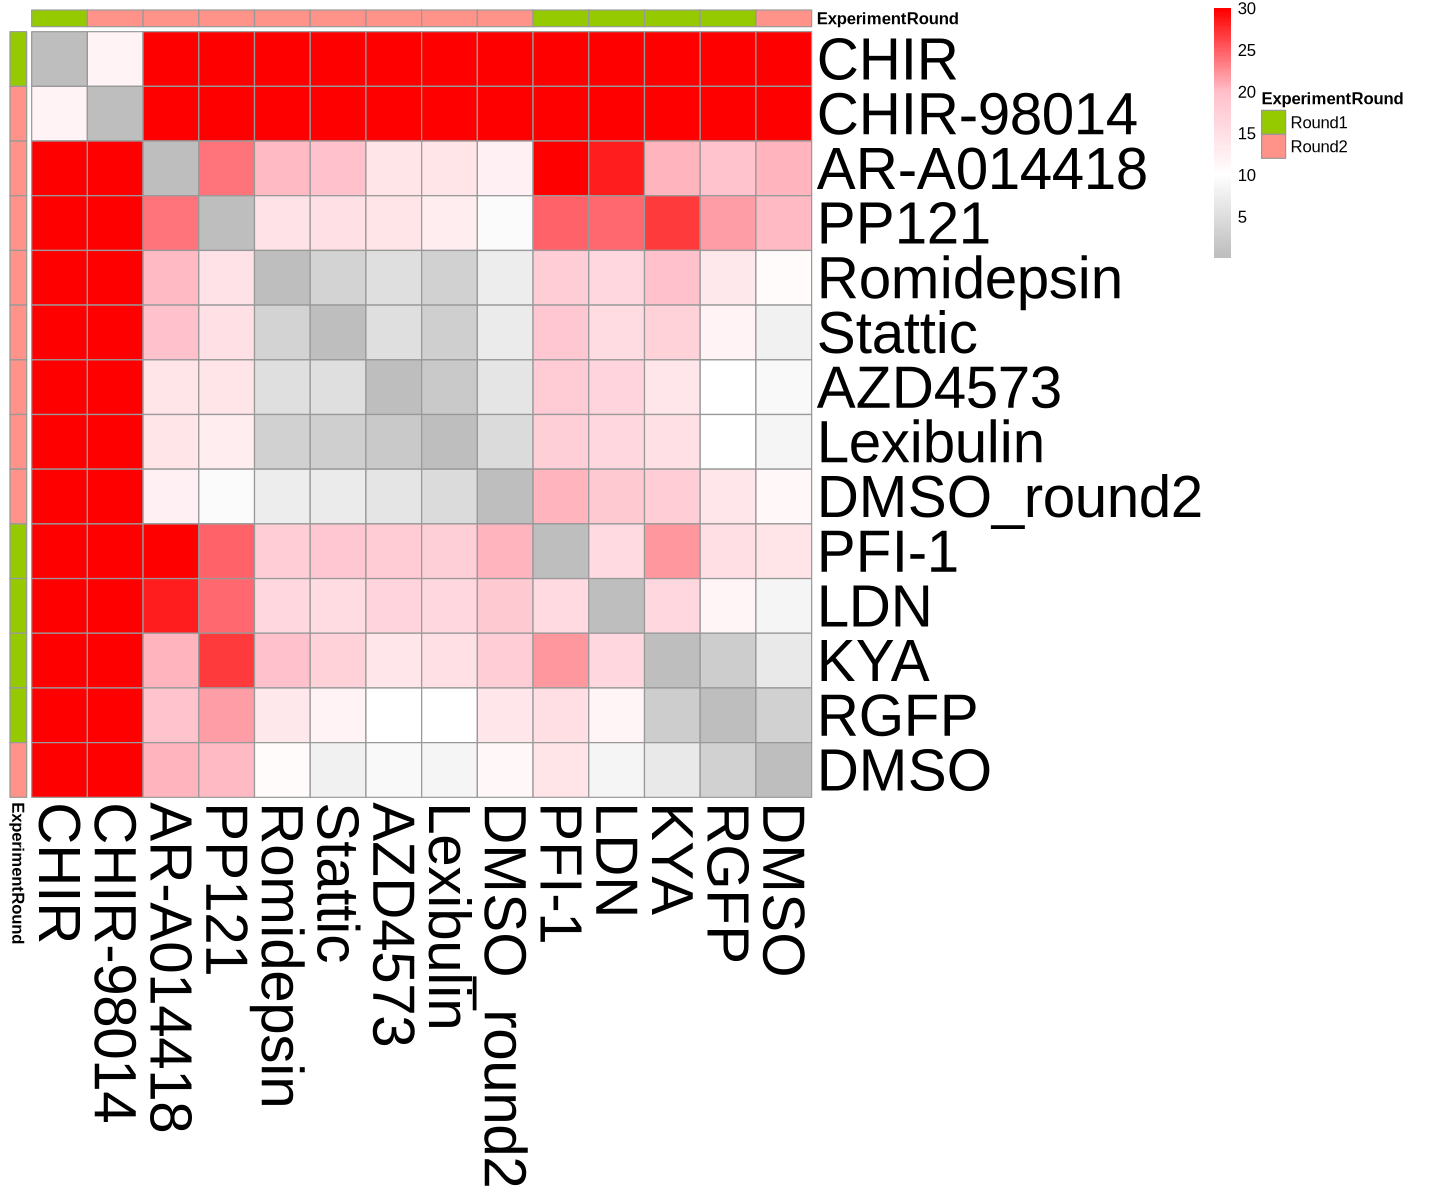

In [33]:
options(repr.plot.width = 12, repr.plot.height = 10)
drug_energyDist=drug_energyDist[rcOrder,rcOrder]
drug_energyDist_copy=copy(drug_energyDist)
drug_energyDist_copy[drug_energyDist_copy>30]=30
pheatmap(drug_energyDist_copy, na_col = "grey", cluster_rows = FALSE,cluster_cols = FALSE, 
         fontsize_row=35,fontsize_col=35, clustering_method = "ward.D2",
          annotation_col=annots, annotation_row=annots,
         color=colorRampPalette(c("grey","white","pink", "red"))(100))

In [18]:
allRes_cosine=list()
for(elem in c("AR-A014418", "AZD4573", "CHIR", "CHIR-98014","DMSO",
              "DMSO_round2", "KYA", "Lexibulin","LDN", "PFI1", "PP121",
              "RGFP", "Romidepsin","Stattic")){
    cosineRes <- read.csv(file.path(elem, paste0(elem, "_cosineRes.csv")))
    cosineRes$pertType="Background"
    cosineRes[cosineRes$perturbation != "control_vs_control","pertType"] = "Knock down"

    
    cosineRes$FDR_cosine = p.adjust(cosineRes$pval_cosine,n = nrow(cosineRes[cosineRes$pertType=="Knock down",]))
    cosineRes$condition=elem 
   
    
    cosineRes$nSign= length(cosineRes[cosineRes$pertType=="Knock down" & cosineRes$pval_cosine < 0.05,"pval_cosine"])
    cosineRes$source_file = NULL
    allRes_cosine <- lappend(allRes_cosine, cosineRes )
}
allRes_cosine = data.frame(do.call(rbind,allRes_cosine))
allRes_cosine$pertSign=FALSE
allRes_cosine[(!is.na(allRes_cosine$pval_cosine) &allRes_cosine$pval_cosine < 0.05),"pertSign"]=TRUE
allRes_cosine=data.table(allRes_cosine)
allRes_cosine[,nSign_200:=sum(pertSign),by="condition"]
allRes_cosine=data.frame(allRes_cosine)

In [19]:
head(allRes_cosine)

,perturbation,n_pert,n_ctrl,cosine_distance_means,z_cosine,pval_cosine,qval_cosine,pertType,FDR_cosine,condition,nSign,pertSign,nSign_200
,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<int>,<lgl>,<int>
1,A1BG,2540,274774,5.090237e-05,-16.934442,1.000000000,1.000000000,Knock down,1,AR-A014418,1230,FALSE,1230
2,AASS,923,274774,4.911423e-04,35.022230,0.000999001,0.001727684,Knock down,1,AR-A014418,1230,TRUE,1230
3,ABCB6,1442,274774,1.496673e-04,-5.278308,1.000000000,1.000000000,Knock down,1,AR-A014418,1230,FALSE,1230
4,ABCC5,1086,274774,1.459122e-04,-5.721481,1.000000000,1.000000000,Knock down,1,AR-A014418,1230,FALSE,1230
5,ABCF1,1134,274774,9.608269e-05,-11.602306,1.000000000,1.000000000,Knock down,1,AR-A014418,1230,FALSE,1230
6,ABCF3,909,274774,2.642274e-04,8.241963,0.000999001,0.001727684,Knock down,1,AR-A014418,1230,TRUE,1230


Warning message:
“Removed 8497 rows containing non-finite outside the scale range (`stat_bin()`).”
Warning message:
“Removed 56 rows containing missing values or values outside the scale range (`geom_bar()`).”


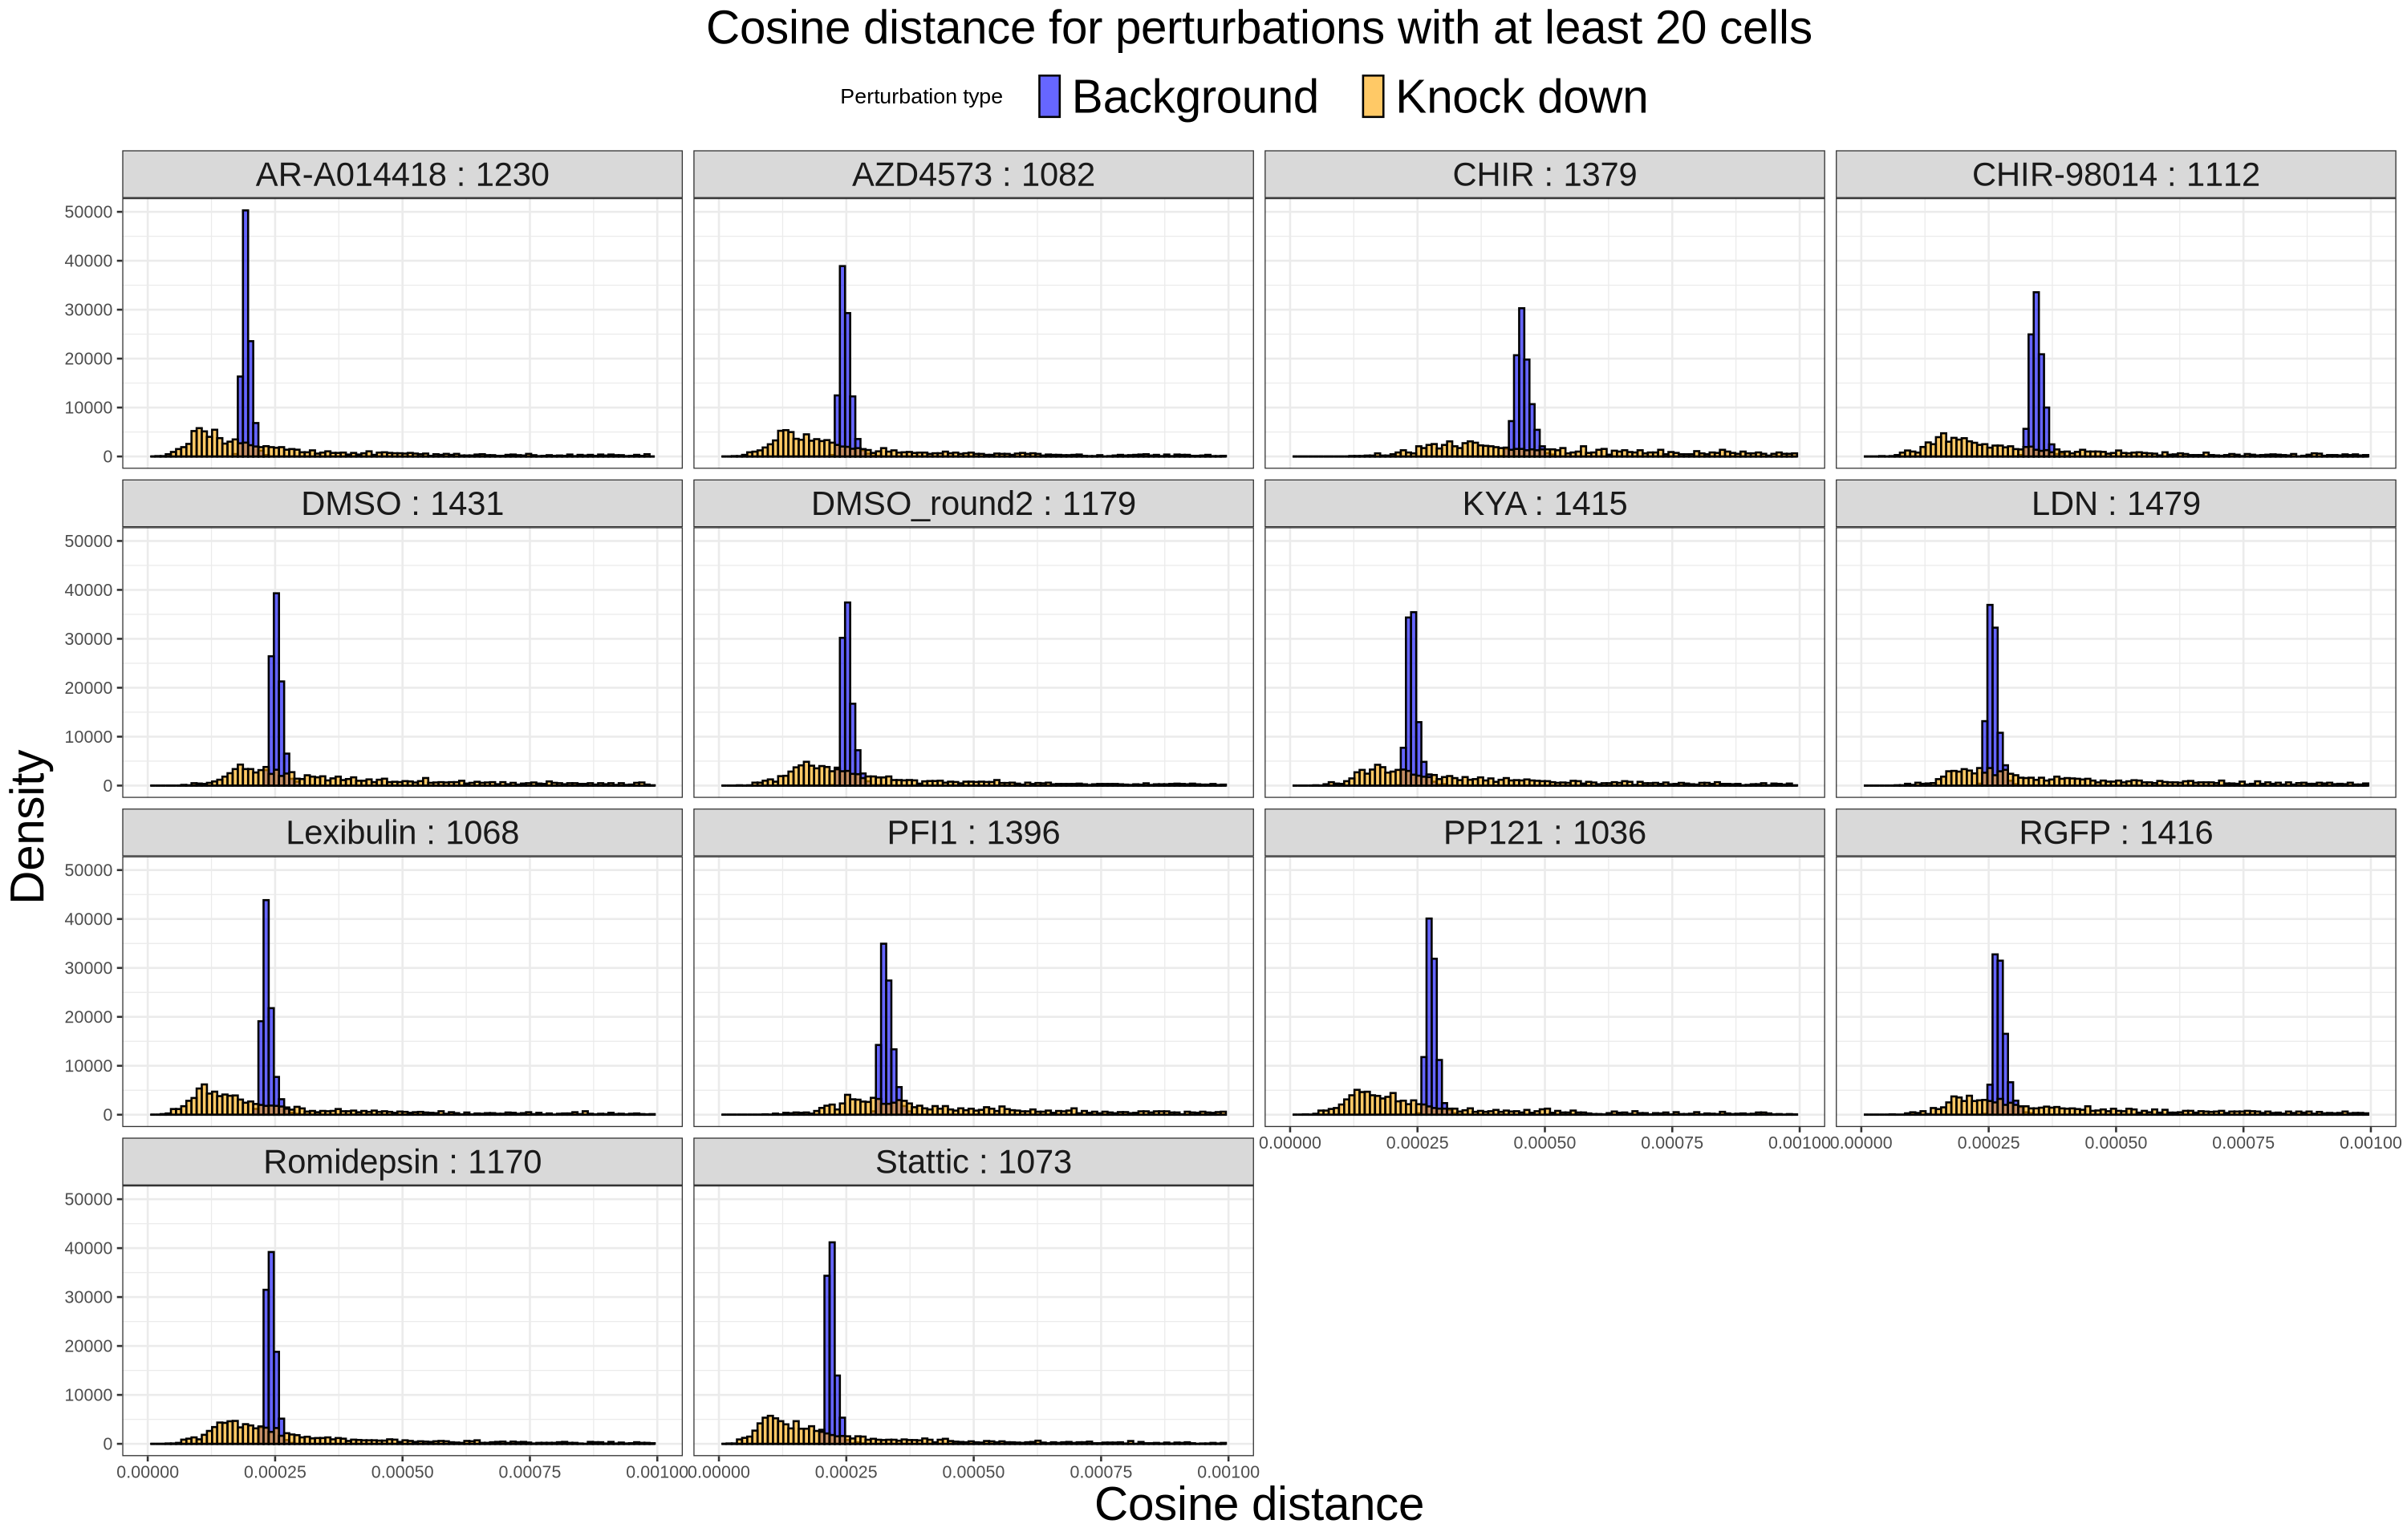

In [20]:
options(repr.plot.width = 25, repr.plot.height = 16)
allRes_cosine$conditionTitle = paste0(allRes_cosine$condition, " : ", 
                                      allRes_cosine$nSign)
ggplot(allRes_cosine, aes(x = cosine_distance_means, fill = pertType)) +
      geom_histogram(aes(y = after_stat(density)),alpha = 0.6,
                     position = "identity", bins = 100, color = "black") +
      facet_wrap(~conditionTitle)+
      theme_bw(base_size = 16) +
      labs(
        title=paste0("Cosine distance for perturbations with at least 20 cells"),
        x = "Cosine distance",
        y = "Density",
        fill = "Perturbation type"
      ) +
      theme(
        legend.position = "top",
          legend.text=element_text(size=35),
          axis.title = element_text(size=35),
        plot.title = element_text(hjust = 0.5,size=35),
        strip.text=element_text(size=25)
      )+scale_fill_manual(
        values = c("blue", "orange")
      )+xlim(0,0.001)

In [ ]:
compute_square_matrices <- function(df) {
  
  # Keep only significant rows
  df_sig <- df[df$pertSign == TRUE, c("condition", "perturbation")]
  
  # Unique conditions
  conditions <- sort(unique(df_sig$condition))
  n <- length(conditions)
  
  # Prepare empty matrices
  mat_nboth <- matrix(0, nrow = n, ncol = n,
                      dimnames = list(conditions, conditions))
  mat_jaccard <- matrix(0, nrow = n, ncol = n,
                        dimnames = list(conditions, conditions))
  
  # Build list mapping condition → significant perturbations
  cond_to_perts <- list()
  for (cond in conditions) {
    cond_to_perts[[cond]] <- unique(df_sig$perturbation[df_sig$condition == cond])
  }
  
  # Fill matrices
  for (i in seq_len(n)) {
    for (j in seq_len(n)) {
      set1 <- cond_to_perts[[conditions[i]]]
      set2 <- cond_to_perts[[conditions[j]]]
      
      inter_size <- length(intersect(set1, set2))
      union_size <- length(union(set1, set2))
      
      mat_nboth[i, j] <- inter_size
      mat_jaccard[i, j] <- if (union_size == 0) 0 else inter_size / union_size
    }
  }
  
  return(list(n_both = mat_nboth, jaccard = mat_jaccard))
}

# ----- Usage -----
result <- compute_square_matrices(allRes_cosine)
n_both_matrix <- result$n_both
jaccard_matrix <- result$jaccard


In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)
SampleSheet=read.csv("./TextFiles/SampleSheet.csv")
rownames(SampleSheet)=SampleSheet$SampleName

SampleSheet <- SampleSheet[rownames(n_both_matrix),]
annots=copy(SampleSheet)
annots$SampleName=NULL

pheatmap(
  n_both_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  annotation_col=annots, annotation_row=annots,
  color = colorRampPalette(c("white", "skyblue", "navy"))(100),
  main = "Number of Shared Significant Perturbations"
)

In [ ]:
pheatmap(
  jaccard_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  color = colorRampPalette(c("white", "lightgreen", "darkgreen"))(100),
  main = "Jaccard Similarity"
)

In [ ]:
options(repr.plot.width = 25, repr.plot.height = 16)
allRes_cosine_min200 <- allRes_cosine[allRes_cosine$n_pert > 200,]
allRes_cosine_min200$conditionTitle = paste0(allRes_cosine_min200$condition, " : ", 
                                      allRes_cosine_min200$nSign_200)

ggplot(allRes_cosine_min200, aes(x = cosine_distance_means, fill = pertType)) +
      geom_histogram(aes(y = after_stat(density)),alpha = 0.6,
                     position = "identity", bins = 100, color = "black") +
      facet_wrap(~conditionTitle)+
      theme_bw(base_size = 16) +
      labs(
        title=paste0("Cosine distance for perturbations with at least 200 cells"),
        x = "Cosine distance",
        y = "Density",
        fill = "Perturbation type"
      ) +
      theme(
        legend.position = "top",
          legend.text=element_text(size=35),
          axis.title = element_text(size=35),
        plot.title = element_text(hjust = 0.5,size=35),
        strip.text=element_text(size=25)
      )+scale_fill_manual(
        values = c("blue", "orange")
      )+xlim(0,0.001)

In [ ]:
result <- compute_square_matrices(allRes_cosine_min200)
n_both_matrix <- result$n_both
jaccard_matrix <- result$jaccard


In [ ]:
dmso_sign=allRes_cosine_min200[(allRes_cosine_min200[,"condition"] %in% c("DMSO","DMSO_round2")),]
dmso_sign = dmso_sign[dmso_sign$pertSign == TRUE,]
write.csv(dmso_sign,"dmso_sign.csv")

In [ ]:
chir_sign=allRes_cosine_min200[(allRes_cosine_min200[,"condition"] %in% c("CHIR","CHIR-98014")),]
chir_sign = chir_sign[chir_sign$pertSign == TRUE,]
write.csv(chir_sign,"CHIR_sign.csv")

In [ ]:
unique(allRes_cosine_min200[,"condition"])

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 10)

pheatmap(
  n_both_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  color = colorRampPalette(c("white", "skyblue", "navy"))(100),
  main = "Number of Shared Significant Perturbations"
)

In [ ]:
pheatmap(
  jaccard_matrix,
  display_numbers = TRUE,
  number_color = "black",
  fontsize_number = 10,
  fontsize_col=15,fontsize_row=15,
  color = colorRampPalette(c("white", "lightgreen", "darkgreen"))(100),
  main = "Jaccard Similarity"
)

In [ ]:
s=unique(allRes_cosine_min200[,c("condition", "nSign_200")])
s=s[order(s$nSign_200),]
s$condition=factor(s$condition, levels=s$condition)

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 6)

ggplot(s, aes(x = condition, y = nSign_200)) +
  geom_bar(stat = "identity", fill = "steelblue") +
  labs(title = "ggplot2 Bar Plot", x = "Category", y = "Value") +
  theme_minimal()+theme(
        axis.text=element_text(size=15),
        axis.title=element_text(size=15),
        axis.text.x=element_text(hjust=1, angle=90)
      )+ylab("Number of perturbations that \n significantly differ from controls")

In [ ]:
#write.csv(allRes_cosine,"ContextSignificance.csv")

In [ ]:
allRes_ModelTrain = copy(allRes_cosine)
allRes_ModelTrain=allRes_ModelTrain[allRes_ModelTrain$n_pert > 199,]

#allRes_ModelTrain = allRes_ModelTrain[allRes_ModelTrain$pertSign == TRUE,]
k=table(allRes_ModelTrain$perturbation)
pertWithCells = names(k>10)
allRes_ModelTrain = allRes_ModelTrain[allRes_ModelTrain$perturbation %in% pertWithCells,]
allRes_ModelTrain_sgn = allRes_ModelTrain[allRes_ModelTrain$pertSign == TRUE,]
mySelPerts=unique(allRes_ModelTrain_sgn$perturbation)

perClust=read.csv("PerturbationClusters_v3.csv", row.names = 1)
perClust$perturbation = rownames(perClust)
perClustLeiden=perClust[,c("perturbation","leiden")]

perClust$perturbation=NULL
perClust$leiden=NULL
perClust[perClust == -10] = NA
perClustLeiden$contextSpecIndex = rowMeans(perClust, na.rm = TRUE)
perClustLeiden = perClustLeiden[perClustLeiden$perturbation %in% mySelPerts,]
#write.csv(perClustLeiden,"SelectedPerturbations.csv")
dim(perClustLeiden)

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 8)
allRes_cosine = allRes_cosine[allRes_cosine$pertType == "Knock down",]
selPerts <- unique(allRes_cosine[allRes_cosine$n_pert > 200,"perturbation"])
allRes_cosine_min200 = allRes_cosine[allRes_cosine$perturbation %in% selPerts,]

allRes_sgn <- allRes_cosine_min200[!is.na(allRes_cosine_min200$cosine_distance_means),]

allRes_sgn_wide=reshape(allRes_sgn[,c("perturbation", "condition", "cosine_distance_means")],
        idvar = "perturbation", timevar = "condition", direction = "wide")

allRes_sgn_wide$cosine_distance_means.NA = NULL

#colnames(allRes_sgn_wide) = c("perturbation", "CHIR","DMSO","KYA","LDN","PFI1","RGFP")

rownames(allRes_sgn_wide) = allRes_sgn_wide$perturbation
allRes_sgn_wide$perturbation = NULL
allRes_sgn_wide[is.na(allRes_sgn_wide)]=0

#allRes_sgn_wide = allRes_sgn_wide*1000
allRes_sgn_wide[allRes_sgn_wide>0.002]=0.002
colnames(allRes_sgn_wide)=sapply(colnames(allRes_sgn_wide),function(x){strsplit(x,"cosine_distance_means.")[[1]][2]})
k=pheatmap(t(allRes_sgn_wide), na_col = "grey", 
  clustering_method = "ward.D2",fontsize_col=1,fontsize_row=15)
pertNames=colnames(t(allRes_sgn_wide))[k$tree_col$order]
condNames=rownames(t(allRes_sgn_wide))[k$tree_row$order]


In [ ]:
allRes_FC_all = data.frame(read.csv("allRes_FC_all_with_empirical_pvals.csv"))

In [ ]:
allRes_FC_all=allRes_FC_all[!is.na(allRes_FC_all$N_totalRegGenes),]

In [ ]:
options(repr.plot.width = 23, repr.plot.height = 12)

ggplot(allRes_FC_all, aes(x = N_totalRegGenes, fill = type)) +
      geom_histogram(aes(y = after_stat(density)),alpha = 0.6, position = "identity", bins = 100, color = "black") +
      facet_wrap(~Condition, ncol=5, scales="free")+
      theme_bw(base_size = 16) +
      labs(
        title=paste0("Number of DE genes with FDR < 0.1"),
        x = "Number of DE genes",
        y = "Density",
        fill = "Perturbation type"
      ) +
      theme(
        legend.position = "top",
        plot.title = element_text(hjust = 0.5)
      )+scale_fill_manual(
        values = c("blue", "red")
      )+xlim(0,1000)

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(allRes_FC_all_KD, aes(y = N_totalRegGenes, x = N_cells)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of cells of the genetic perturbation",
    y = "Number of DE genes (FDR < 0.1)"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) +geom_vline(xintercept = 200, color="red")


In [ ]:
selPert=unique(allRes_FC_all_KD[allRes_FC_all_KD$N_cells > 200,"PerturbationName"])
allRes_FC_all_KD_sgn = allRes_FC_all_KD[allRes_FC_all_KD$PerturbationName %in% pertNames,]
allRes_FC_sgn_wide=reshape(allRes_FC_all_KD_sgn[,c("PerturbationName", "Condition", "N_totalRegGenes")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_totalRegGenes.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100
condNames=condNames[condNames != 'Stattic']
pheatmap(t(allRes_FC_sgn_wide)[condNames,pertNames], 
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
dim(t(allRes_FC_sgn_wide))

In [ ]:
pertNames[which(pertNames %ni% colnames(t(allRes_FC_sgn_wide)))]

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
allRes_FC_all_KD_KOEf = allRes_FC_all_KD[!is.na(allRes_FC_all_KD$Mean_KOEf),]
ggplot(allRes_FC_all_KD_KOEf, aes(x = N_totalRegGenes, y = Mean_KOEf)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    title = "Number of DE genes with FDR < 0.1",
    x = "Number of DE genes",
    y = "Median KD efficiency"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) +
  ylim(-1, 1)


In [ ]:
allRes_cosine_tmp = allRes_cosine[,c("perturbation","n_pert","condition","cosine_distance_means")]

In [ ]:
colnames(allRes_cosine_tmp)=c("PerturbationName", "n_pert", "Condition", "cosine_distance_means")

In [ ]:
tmp=merge(allRes_FC_all_KD,allRes_cosine_tmp,by=c("Condition","PerturbationName"))

In [ ]:
length(unique(allRes_FC_all_KD$PerturbationName))

In [ ]:
str(tmp)
tmp <- tmp[!is.na(tmp$cosine_distance_means),]
tmp <- tmp[!is.na(tmp$N_totalRegGenes),]

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(tmp, aes(y = cosine_distance_means, x = N_totalRegGenes)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of DE genes (FDR < 0.1)",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) 


In [ ]:
head(tmp)

In [ ]:
library(ggpubr)

options(repr.plot.width = 23, repr.plot.height = 12)
ggplot(tmp, aes(y = cosine_distance_means, x = n_pert)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of cells of the genetic perturbation",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) + geom_vline(xintercept = 200, color="red")


In [ ]:
options(repr.plot.width = 23, repr.plot.height = 12)
tmp_min200 = tmp[tmp$n_pert >= 200,]
ggplot(tmp_min200, aes(y = cosine_distance_means, x = N_totalRegGenes)) +
  geom_point(alpha = 0.2) +
  stat_cor(method = "pearson", label.x = Inf, label.y = Inf, 
           vjust = 1.5, hjust = 1.1, size = 4) +
  facet_wrap(~ Condition, ncol = 5, scales = "free") +
  theme_bw(base_size = 16) +
  labs(
    x = "Number of DE genes (FDR < 0.1)",
    y = "Cosine distance based on mean expression"
  ) +
  theme(
    legend.position = "top",
    plot.title = element_text(hjust = 0.5)
  ) 


In [ ]:
length(pertNames)

In [ ]:
perClust=read.csv("PerturbationClusters_v3.csv", row.names = 1)

In [ ]:
perClust

In [ ]:
library(pheatmap)
library(RColorBrewer)
library(data.table)

perClust$leiden <- factor(
  perClust$leiden,
  levels = c('0','7','2',
             '19','3','18','10',
             '5','14','1','20','9','11',
             '12','16','17','13','15','8',
             '6','4')
)

# order rows by leiden
perClust <- perClust[order(perClust$leiden), ]

# ---- row annotation for pheatmap ----
row_annot <- data.frame(
  leiden = perClust$leiden
)
rownames(row_annot) <- rownames(perClust)

# make enough distinct colors for all leiden levels
n_clust <- length(levels(perClust$leiden))
base_cols <- brewer.pal(12, "Paired")  # max 12
leiden_cols <- colorRampPalette(base_cols)(n_clust)

annot_colors <- list(
  leiden = setNames(leiden_cols, levels(perClust$leiden))
)

# ---- matrix for heatmap ----
perClust_tmp <- copy(perClust)
perClust_tmp[perClust_tmp == -10] <- NA
perClust_tmp$leiden <- NULL
perClust_tmp[perClust_tmp > 0.5] <- 0.5

options(repr.plot.width = 23, repr.plot.height = 20)

s<-pheatmap(
  perClust_tmp,
  cluster_rows = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)
condPairNames=colnames(perClust_tmp)[s$tree_col$order]


In [ ]:
condPairNames

In [ ]:
jaccardSims=read.csv("JaccardSims.csv", row.names = 1)
jaccardSims[jaccardSims==-1]=NA
jaccardSims <- jaccardSims[rownames(perClust_tmp), colnames(perClust_tmp)]

jaccardSims[jaccardSims>0.3]=0.3
pheatmap(
  jaccardSims[,condPairNames],
  
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)

In [ ]:
jaccardSims

In [ ]:

pheatmap(
  perClust_tmp[rownames(perClust_tmp) %in% pertNames, condPairNames],
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  clustering_method = "ward.D2",
  na_col = "grey",
  fontsize_col = 25,
  fontsize_row = 2,
  color = colorRampPalette(c("navy", "lightblue", "white", "yellow", "orange"))(100),
  annotation_row = row_annot,
  annotation_colors = annot_colors
)
condPairNames=colnames(perClust_tmp)[s$tree_col$order]


In [ ]:
options(repr.plot.width = 13, repr.plot.height = 8)


allRes_FC_sgn_wide=reshape(allRes_FC_all_KD[,c("PerturbationName", "Condition", "N_totalRegGenes")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_totalRegGenes.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100
condNames=condNames[condNames != 'Stattic']
pheatmap(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]], 
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
dim(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]])

In [ ]:
options(repr.plot.width = 13, repr.plot.height = 8)


allRes_FC_sgn_wide=reshape(allRes_FC_all_KD[,c("PerturbationName", "Condition", "N_cells")],
                           idvar = "PerturbationName", timevar = "Condition", direction = "wide")

rownames(allRes_FC_sgn_wide) = allRes_FC_sgn_wide$PerturbationName
allRes_FC_sgn_wide$PerturbationName = NULL
colnames(allRes_FC_sgn_wide)=sapply(colnames(allRes_FC_sgn_wide),function(x){strsplit(x,"N_cells.")[[1]][2]})


for(elem in colnames(allRes_FC_sgn_wide)){
    allRes_FC_sgn_wide[,elem]=as.numeric(allRes_FC_sgn_wide[,elem])
}

allRes_FC_sgn_wide[is.na(allRes_FC_sgn_wide)]=0

allRes_FC_sgn_wide[allRes_FC_sgn_wide>1000]=1000
#allRes_FC_sgn_wide[allRes_FC_sgn_wide<100]=100
condNames=condNames[condNames != 'Stattic']
pheatmap(t(allRes_FC_sgn_wide)[condNames,rownames(perClust_tmp)[rownames(perClust_tmp) %in% pertNames]], 
         na_col = "grey", cluster_rows=FALSE,cluster_cols=FALSE,fontsize_col=1,fontsize_row=25)

In [ ]:
t(allRes_FC_sgn_wide)

In [ ]:
for(elem in unique(perClust$leiden)){
    print("*********************************************")
    print(elem)
    print(rownames(perClust[perClust$leiden==elem,]))
}